### Data Visualization

In [2]:
import pandas as pd, numpy as np 
import matplotlib.pyplot as plt , matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
pd.set_option('display.max_columns',None)

In [4]:
df = pd.read_csv("cleaned_movie_dataset.csv")

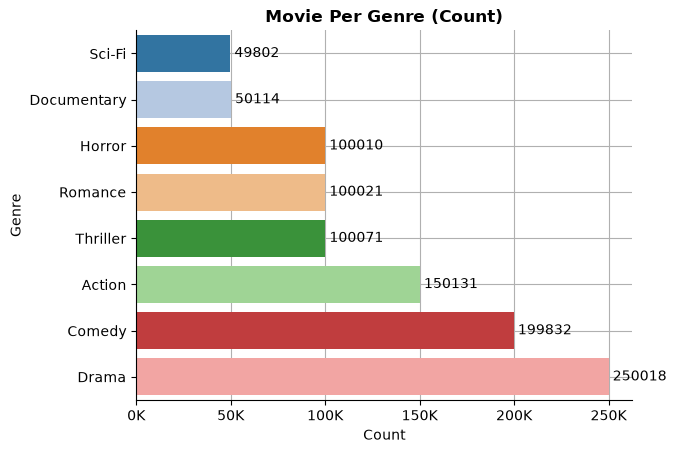

In [5]:
# Movies Per Genre(Count) Bar plot 

# calculating movies by genre
genre_count = df.groupby('Genre').agg(
    Count = ('MovieID', 'count')
).sort_values('Count',ascending = True)

# Plotting bar plot
ax = sns.barplot(data = genre_count,
         y='Genre',
         x='Count',
        hue = 'Genre',
        palette = 'tab20',
        legend = False)

# Add exact count values for every bar
for con in ax.containers:
    ax.bar_label(con,fmt='%d',padding = 3)

# Formatting x-axis ticks
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_:f'{x/1000:.0f}K')
)

sns.despine()  # removing top and right border
plt.title('Movie Per Genre (Count)', fontweight ='bold') # Plot title
ax.set_axisbelow(True) # Push grid lines behind the bar
plt.grid(True,linestyle = "-",alpha=1) # Adding a solid grid
plt.show()


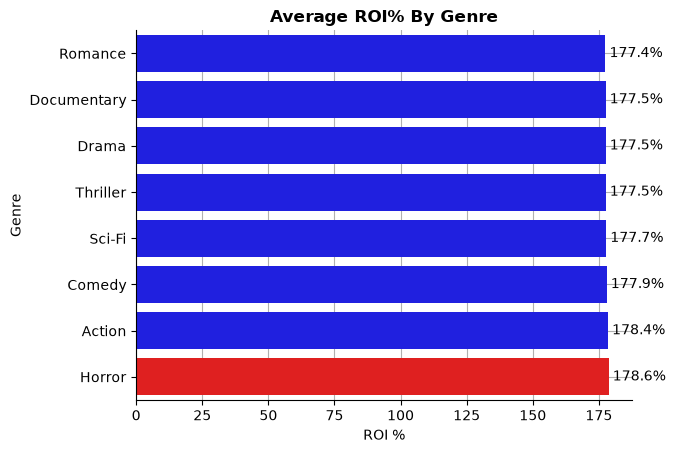

In [19]:
# Average ROI% by Genre


# Calculate average ROI by genre
genre_roi = df.groupby('Genre',observed = True).agg(
    roi = ('ROI_pct' , 'mean')
).sort_values('roi',ascending = True)

# HighLight the max value, and standard color for rest 
max_roi = genre_roi['roi'].max()
color = ['Red' if ro == max_roi else 'Blue' for ro in genre_roi['roi'] ]

# Plotting the graph
ax = sns.barplot(data = genre_roi,
           y='Genre',
           x='roi',
           palette = color,
           legend =False
           )

# labels after the bars
for con in ax.containers:
    ax.bar_label(con,fmt='%.1f%%',padding = 3)

    
sns.despine() # Removing the top and right border
plt.title('Average ROI% By Genre' , fontweight ='bold')  # Plot Title
ax.set_axisbelow(True)  # Push grid lines behind the bar
plt.xlabel('ROI %') # X-axis label
plt.grid(True,linestyle='-',alpha =1) # Adding grid
plt.show()


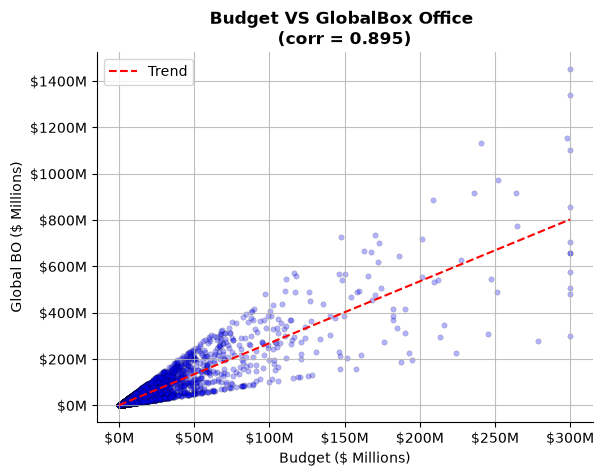

In [75]:
# Budget VS Global Box Office (sample = 10000)
# correlation = 0.895

# Extracting Sample data (~10000)
sample = df.sample(10000,random_state =42)

# plotting scatte plot
ax = sns.scatterplot( data = sample,
                x= sample['BudgetUSD']/1e6,
                y= sample['Global_BoxOfficeUSD']/1e6,
                color = 'blue',
                edgecolor='black',
                s=15,
                alpha=0.3)

# Formatting x-axis ticks  
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_:f'${x:.0f}M')
)

# Fromatting y-axis ticks
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_:f'${x:.0f}M')
)


# Adding Trend Line

# Calculating slope(m) and intercept(b) for  => y = mx + b (Straight Line)
m,b = np.polyfit( sample['BudgetUSD']/1e6 , sample['Global_BoxOfficeUSD']/1e6 , 1 )

# Using linspace create a smooth Trend Line using only 100 data points
x_trend = np.linspace(0 , sample['BudgetUSD'].max()/1e6 , 100)
y_trend = m * x_trend + b  

#Plotting the Trend Line
plt.plot(x_trend,y_trend,color='red',linestyle='--',linewidth = 1.5,label='Trend')


sns.despine() # Removing top and right border
plt.legend() # Showing labels
plt.title('Budget VS GlobalBox Office \n(corr = 0.895)' , fontweight = 'bold') # Plot Title
plt.xlabel('Budget ($ Millions)')  # X-axis Label
plt.ylabel('Global BO ($ Millions)')  # Y-axis Label
plt.grid(True,linestyle='-', alpha=0.8) # Adding grid
plt.show()

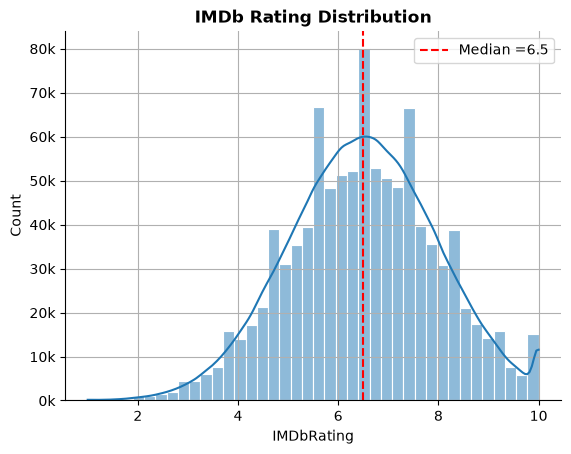

In [78]:
# IMDB Rating Distribution

# Plotting the graph
ax = sns.histplot(data = df,
           x='IMDbRating',
           stat='count',
           edgecolor = 'white',
           kde = True,
           bins=40
           )

# Median Line
ax.axvline(df['IMDbRating'].median(),
           color = 'red',
           linewidth = 1.5,
           linestyle='--',
           label =f"Median ={df['IMDbRating'].median():.1f}")

# Formatting y-axis Text
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_:f'{x/1000:.0f}k')
)

sns.despine() # Removing top and right border
plt.legend() # showing labels
plt.title('IMDb Rating Distribution',fontweight='bold') # Plot Title
plt.grid(True,linestyle='-',alpha=1) # Adding grid
plt.show()

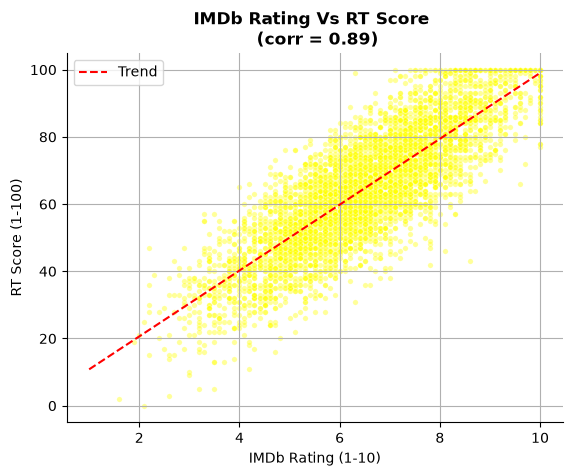

In [86]:
# IMDb Rating VS RT Score

# Extracting  sample data
sample = df.sample(5000, random_state =42)

# Plotting scatter chart
ax = sns.scatterplot(
    data = sample,
    x= sample['IMDbRating'],
    y= sample['RottenTomatoesScore'],
    s=15,
    color = 'yellow',
    edgecolor='white',
    alpha = 0.4
)

# Trend Line

# Calculating m and b for => y = mx + b 
m,b = np.polyfit(sample['IMDbRating'],sample['RottenTomatoesScore'],1)

# Creating a smooth Trend line using 100 data points
x_trend = np.linspace(1,10,100)
y_trend = m * x_trend + b

plt.plot(x_trend, y_trend , linewidth = 1.5,linestyle='--', color = 'red' ,label='Trend')

sns.despine() # Removing top and right border
plt.legend() # showing labels
plt.title('IMDb Rating Vs RT Score \n (corr = 0.89)', fontweight = 'bold') # Plot Title
plt.xlabel('IMDb Rating (1-10)') # X-axis label
plt.ylabel('RT Score (1-100)')  # Y-axis label
plt.grid(True, linestyle='-' , alpha = 1)  # Adding grid
plt.show()

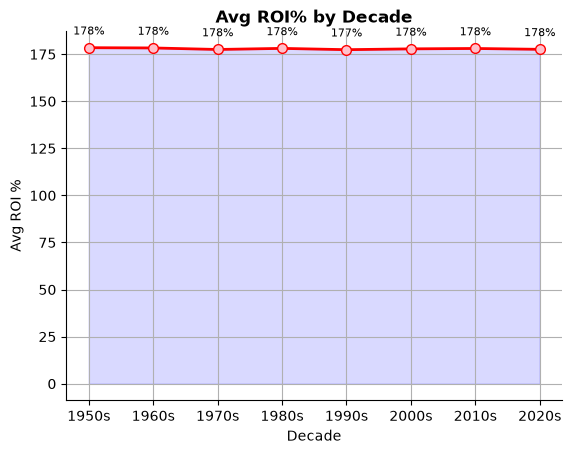

In [22]:
# Avg ROI% by Decade

# grouping the data and sorting by index
decade_roi = df.groupby('Decade', observed=True)['ROI_pct'].mean().sort_index()

# plotting the graph
ax = plt.plot(decade_roi.index, 
              decade_roi.values,
              marker='o', 
              color='red',
              linewidth=2,
              markersize=7,
              markerfacecolor='pink')

# fill the area underneath
plt.fill_between(decade_roi.index, 
                 decade_roi.values, 
                 alpha=0.15,
                 color='blue')

# Annotate data points with their values
for x,y in zip(decade_roi.index,decade_roi.values):
    plt.text(
        x,y+7,
        f'{y:.0f}%',
        ha='center',
        fontsize = 8
    )
    

sns.despine() # Removing top and right border
plt.title('Avg ROI% by Decade',fontweight = 'bold') # Plot Title
plt.xlabel('Decade') # X-axis lable
plt.ylabel('Avg ROI %')  # Y-axis label
plt.grid(True,linestyle='-',alpha =1) # Adding grid
plt.show()


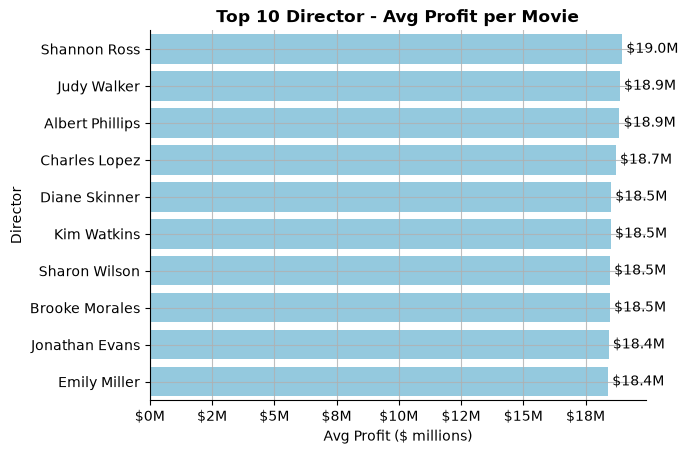

In [93]:
# Top 10 director Avg profit per movie

# Groupping the data
dir_top =  df.groupby('Director',observed = True).agg(
    avg = ('ProfitUSD','mean')
).sort_values('avg', ascending = False).head(10)

# Plotting Bar graph
ax = sns.barplot(
    data = dir_top,
    x=dir_top['avg']/1e6,
    y='Director',
    color = 'skyblue'
)

# data points with values 
for con in ax.containers:
    ax.bar_label(con,fmt='$%.1fM',padding = 3)

# formatting x-axis Values
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_:f'${x:.0f}M')
)

sns.despine()  # Removing top and right border
plt.title("Top 10 Director - Avg Profit per Movie", fontweight = 'bold')  # Plot Title
plt.xlabel('Avg Profit ($ millions)') # X-axis label
plt.grid(True, linestyle='-',alpha =0.8)  # Adding grid
plt.show()

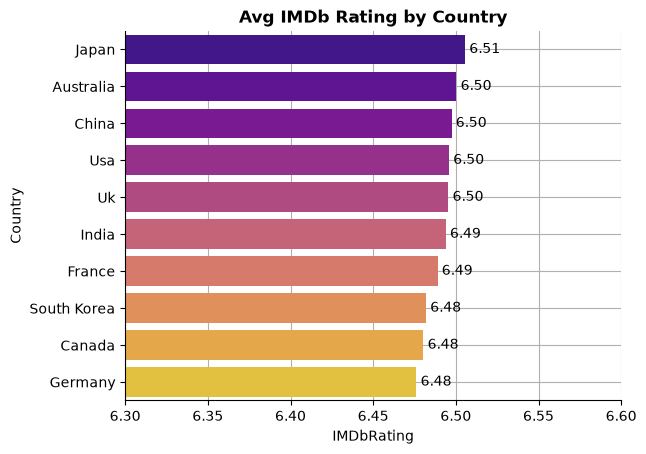

In [82]:
# Avg IMDb Rating by Country

# Grouping the data 
coun_avg =(
    df.groupby('Country',observed = True)['IMDbRating']
    .mean()
    .reset_index()
    .sort_values('IMDbRating',ascending = False)
    
) 

# Plotting the bar plot
ax = sns.barplot(
    data = coun_avg,
    x = 'IMDbRating',
    y = 'Country',
    palette = 'plasma'
)

# adding values for every data points
for con in ax.containers:
    ax.bar_label(con,fmt='%.2f',padding = 3)


sns.despine()  # Removing top and right border
plt.xlim(6.30,6.60) # Limiting x-axis values
ax.set_axisbelow(True) # Push grid lines behind the bar
plt.title('Avg IMDb Rating by Country', fontweight ='bold') # Plot Title
plt.grid(True,linestyle='-',alpha = 1)  # Adding grid
plt.show()

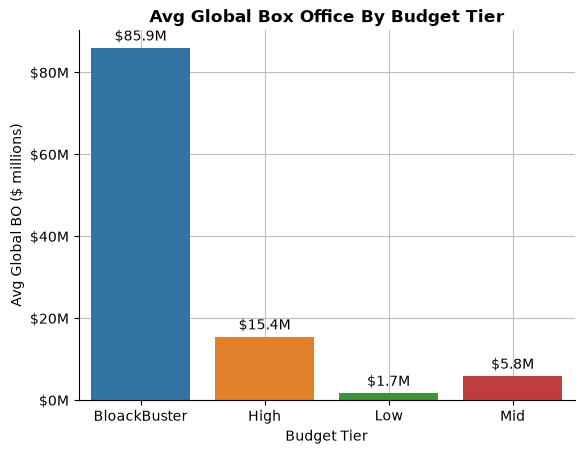

In [90]:
avg_budget = df.groupby('BudgetTier',observed=True).agg(
    avg = ('Global_BoxOfficeUSD','mean')
)

ax = sns.barplot(
    data = avg_budget,
    x='BudgetTier',
    y=avg_budget['avg']/1e6,
    hue = 'BudgetTier',
    legend = False
    
)

for con in ax.containers:
    ax.bar_label(con,fmt='$%.1fM',padding=3)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_:f'${x:.0f}M')
)

sns.despine()  # Removing top and right border
ax.set_axisbelow(True)
plt.title('Avg Global Box Office By Budget Tier',fontweight = 'bold')  # Plot Title
plt.xlabel('Budget Tier') # X-axis label
plt.ylabel('Avg Global BO ($ millions)')  # Y-axis label
plt.grid(True,linestyle='-',alpha=0.8)  # Adding grid
plt.show()



Image saved


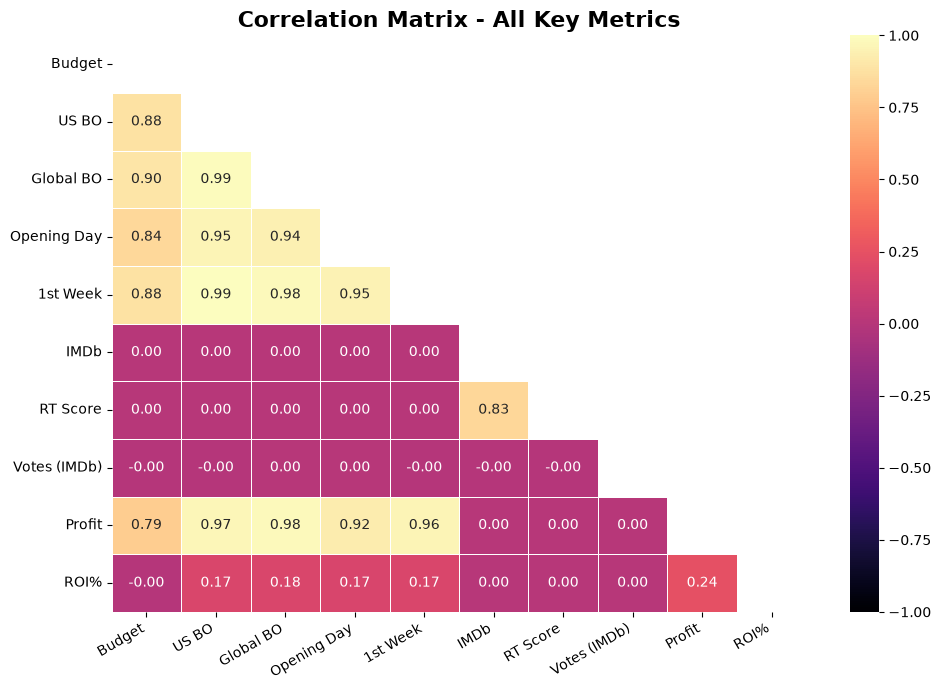

In [6]:
# Correlation Matrix

# numerical columns for correlation
num_col = ['BudgetUSD',
           'US_BoxOfficeUSD',
           'Global_BoxOfficeUSD',
           'Opening_Day_SalesUSD',
           'One_Week_SalesUSD',
           'IMDbRating',
           'RottenTomatoesScore',
           'NumVotesIMDb',
           'ProfitUSD',
           'ROI_pct']

# correlation matrix for the selected features
corr_matrix = df[num_col].corr()

# short labels for the heatmap
labels = ['Budget','US BO','Global BO','Opening Day','1st Week','IMDb','RT Score','Votes (IMDb)','Profit','ROI%']

# figure dimensions
plt.figure(figsize=(10,7))

# mask to hide the upper triangle of the matrix
mask = np.triu(np.ones_like(corr_matrix,dtype=bool))

# Generate the heatmap
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot = True,
    fmt='.2f',
    cmap = 'magma',
    xticklabels=labels,
    yticklabels=labels,
    vmin=-1,vmax=1,
    linewidths = 0.5
)

plt.xticks(rotation=30,ha='right')  # Rotate x-axis labels
plt.title('Correlation Matrix - All Key Metrics', fontweight = 'bold', fontsize = 16)  # Chart title 
plt.tight_layout()  # Adjust layout
plt.savefig('D:/DA_Project/Movie Analysis/movies_correlation.png',bbox_inches = 'tight',dpi=150)
print('Image saved')